# Real Estate Market Analysis

Yandex.Real Estate data — is an archive of apartment listings in St. Petersburg and neighboring towns spanning several years. We would like to learn how to determine the market value of real estate. Setting key parameters to it will allow us to build an automated system that will detect anomalies and fraudulent activity.

Two types of data are available for each apartment for sale. The first is entered by the user, the second is automatically obtained based on map data. For example, the distance to the city center, the airport, the nearest park, and a pond. 

## Contents:
* [Step 1. General Information](#first-bullet)
* [Step 2. Data Preprocessing](#second-bullet)
* 2.1. [Changing Data Types](#second-1-bullet)
* 2.2. [Working with Gaps](#second-2-bullet)
* 2.3. [Finding Duplicates](#second-3-bullet)
* [Step 3. Calculation](#third-bullet)
* 3.1. [Price per Square Meter](#third-1-bullet)
* 3.2. [Day of Week, Month, and Year of Listing](#third-2-bullet)
* 3.3. [Apartment's Floor Location](#third-3-bullet)
* 3.4. [Ratio of Living Space to Total Area / Ratio of Kitchen Area to Total Area](#third-4-bullet)
* [Step 4. Exploratory Data Analysis](#thourth-bullet)
* 4.1.1. [Parameter: Area](#thourth-1-1-bullet)
* 4.1.2. [Parameter: Price](#thourth-1-2-bullet)
* 4.1.3. [Parameter: Number of Rooms](#thourth-1-3-bullet)
* 4.1.4. [Parameter: Ceiling Height](#thourth-1-4-bullet)
* 4.1.5. [Parameter: Time to Sell an Apartment](#thourth-1-5-bullet)
* 4.2.[Factors Affecting Apartment Price](#thourth-2-bullet)
* 4.2.1. [Price per Square Meter as a Factor Affecting Apartment Price](#thourth-2-1-bullet)
* 4.2.2. [Number of Rooms in an Apartment as a Factor Affecting Apartment Price](#thourth-2-2-bullet)
* 4.2.3. [Distance from the Center as a Factor Affecting Apartment Price](#thourth-2-3-bullet)
* 4.2.4. [Apartment Floor as a Factor Affecting Apartment Price](#thourth-2-4-bullet)
* 4.2.5. [Day of the Week as a Factor Affecting Apartment Price](#thourth-2-5-bullet)
* 4.2.6. [Month as a Factor Affecting Apartment Price](#thourth-2-6-bullet)
* 4.2.7. [Year as a Factor Influencing Apartment Price](#thourth-2-7-bullet)
* 4.3. [10 Towns with the Largest Number of Listings](#thourth-3-bullet)
* 4.4. [Housing Analysis in the Center of St. Petersburg](#thourth-4-bullet)
* 4.4.1 [Price Dependence on Distance to the Center (St. Petersburg)](#thourth-4-1-bullet)
* 4.4.2 [Area (Apartments in the Center of St. Petersburg)](#thourth-4-2-bullet)
* 4.4.3 [Price (Apartments in the Center of St. Petersburg)](#thourth-4-3-bullet)
* 4.4.4 [Number of Rooms (Apartments in the Center of St. Petersburg)](#thourth-4-4-bullet)
* 4.4.5 [Ceiling Height (Apartments in the Center of St. Petersburg)](#thourth-4-5-bullet)
* 4.4.6 [Factors Affecting the Price of an Apartment (Center of St. Petersburg)](#thourth-4-6-bullet)
* [Step 5. General Conclusion](#5-bullet)

### Step 1. General Information<a class="anchor" id="first-bullet"></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/real_estate_data.csv', sep='\t', decimal=',')

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.7,16.0,51.0,8,NaN,False,False,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,False,False,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,False,False,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,False,False,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


**Data Description**

* airports_nearest — distance to the nearest airport in meters (m)
* balcony — number of balconies
* ceiling_height — ceiling height (m)
* cityCenters_nearest — distance to the city center (m)
* days_exposition — number of days the listing was posted (from publication to removal)
* first_day_exposition — publication date
* floor — floor
* floors_total — total number of floors in the building
* is_apartment — apartment (boolean)
* kitchen_area — kitchen area in square meters (m²)
* last_price — price at the time of removal
* living_area — living area in square meters (m²)
* locality_name — name of the locality
* open_plan — open plan (boolean)
* parks_around3000 — number of parks within a 3 km radius
* parks_nearest — distance to the nearest park (m)
* ponds_around3000 — number of ponds within a 3 km radius
* ponds_nearest — distance to the nearest pond (m)
* rooms — number of rooms
* studio — studio apartment (boolean)
* total_area — apartment area in square meters (m²)
* total_images — number of photos of the apartment in the listing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   total_images          23699 non-null  int64 
 1   last_price            23699 non-null  object
 2   total_area            23699 non-null  object
 3   first_day_exposition  23699 non-null  object
 4   rooms                 23699 non-null  int64 
 5   ceiling_height        14504 non-null  object
 6   floors_total          23613 non-null  object
 7   living_area           21796 non-null  object
 8   floor                 23699 non-null  int64 
 9   is_apartment          2775 non-null   object
 10  studio                23699 non-null  bool  
 11  open_plan             23699 non-null  bool  
 12  kitchen_area          21421 non-null  object
 13  balcony               12180 non-null  object
 14  locality_name         23650 non-null  object
 15  airports_nearest      18157 non-null

* The table has 22 columns and 23 699 rows.
* There are missing values ​​in 14 columns.
* The ['is_apartment'] column must have its data type changed to boolean.
* The ['first_day_exposition'] column must have its values ​​converted from string to date and time.
* The values ​​in 14 columns must be converted from string to numeric to be able to work with the data and perform calculations.


### Step 2. Data Preprocessing<a class="anchor" id="second-bullet"></a>

### 2.1. Changing Data Types<a class="anchor" id="second-1-bullet"></a>

In [6]:
df['last_price'] = pd.to_numeric(df['last_price'], errors='coerce')
df['last_price'] = df['last_price'].astype('int') 

In [7]:
df['floors_total'] = pd.to_numeric(df['floors_total'], errors='coerce')
df['floors_total'] = df[df['floors_total'].notnull()]['floors_total'].astype('int')

In [8]:
df['airports_nearest'] = pd.to_numeric(df['airports_nearest'], errors='coerce')

In [9]:
df['cityCenters_nearest'] = pd.to_numeric(df['cityCenters_nearest'], errors='coerce')

In [10]:
df['parks_around3000'] = pd.to_numeric(df['parks_around3000'], errors='coerce')

In [11]:
df['total_area'] = pd.to_numeric(df['total_area'], errors='coerce')

In [12]:
df['parks_nearest'] = pd.to_numeric(df['parks_nearest'], errors='coerce')

In [13]:
df['ponds_around3000'] = pd.to_numeric(df['ponds_around3000'], errors='coerce') 

In [14]:
df['ponds_nearest'] = pd.to_numeric(df['ponds_nearest'], errors='coerce')

In [15]:
df['first_day_exposition'] = pd.to_datetime(df['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

In [16]:
df['balcony'] = pd.to_numeric(df['balcony'], errors='coerce')
df['balcony'] = df[df['balcony'].notnull()]['balcony'].astype('int')

In [17]:
df['ceiling_height'] = pd.to_numeric(df['ceiling_height'], errors='coerce')

In [18]:
df['living_area'] = pd.to_numeric(df['living_area'], errors='coerce')

In [19]:
df['kitchen_area'] = pd.to_numeric(df['kitchen_area'], errors='coerce')

In [20]:
df['days_exposition'] = pd.to_numeric(df['days_exposition'], errors='coerce') 

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23699 non-null  int64         
 1   last_price            23699 non-null  int64         
 2   total_area            23699 non-null  float64       
 3   first_day_exposition  23699 non-null  datetime64[ns]
 4   rooms                 23699 non-null  int64         
 5   ceiling_height        14504 non-null  float64       
 6   floors_total          23613 non-null  float64       
 7   living_area           21796 non-null  float64       
 8   floor                 23699 non-null  int64         
 9   is_apartment          2775 non-null   object        
 10  studio                23699 non-null  bool          
 11  open_plan             23699 non-null  bool          
 12  kitchen_area          21421 non-null  float64       
 13  balcony         

    The data types of all columns were changed where necessary,
    except ['is_apartment']. When changing to a boolean type, all missing values
    are changed to True, which is incorrect. The type will be changed later, after working with
    the missing values.

### 2.2 Working with Gaps<a class="anchor" id="second-2-bullet"></a>

In [22]:
df['balcony'].isna().sum()

11519

    There are 11 519 missing values ​​in the ['balconies'] column. If a person didn't indicate the number of balconies, they most likely don't have any. We'll replace such missing values ​​with 0.

In [23]:
df['balcony'] = df['balcony'].fillna(value=0.0)

In [24]:
df['balcony'].isna().sum()

0

    There are no more missing values ​​in the ['balcony'] column.

In [25]:
df['is_apartment'].isna().sum()

20924

    There are 20 924 missing values ​​in the ['is_apartment'] column.
    If a person hasn't indicated that this is not a residential property
    (not classified as a residential property, but having the necessary conditions for occupancy), then it is
    a residential property. We will replace such missing values ​​with False.

In [26]:
df['is_apartment'] = df['is_apartment'].fillna(value=False)
df['is_apartment'].replace('False', False)
df['is_apartment'].replace('True', True)
df['is_apartment'] = df['is_apartment'].fillna(value=False)
df['is_apartment'] = df['is_apartment'].astype('bool')

In [27]:
df['is_apartment'].value_counts()

False    23649
True        50
Name: is_apartment, dtype: int64

In [28]:
df['ceiling_height'].isnull().sum()

9195

    There are 9 195 missing values ​​in the ['ceiling_height'] column. 
    This data was entered by users when they submitted their listing. 
    It could be human error – they forgot to include it.

    According to statistics for 2019, the average ceiling height is 2.7 m. 
    Let's compare it with the median in our table.

In [29]:
df['ceiling_height'].describe()

count    14504.000000
mean         2.771499
std          1.261056
min          1.000000
25%          2.520000
50%          2.650000
75%          2.800000
max        100.000000
Name: ceiling_height, dtype: float64

    The median ceiling height is 2.65 meters, the average is 2.77 meters.

    We see anomalous values ​​in the data: the minimum ceiling height is 1 meter
    and the maximum ceiling height is 100 meters, which affects the average value.

    Statistically, the lowest ceilings in Khrushchev-era buildings are 2.4 meters, 
    while the highest in Stalin-era buildings are 4 meters. 
    Modern standards: minimum 2.5 meters, maximum 3.2 meters.

    Since the table may include older buildings, we'll take a cross-section of the data for ceiling heights
    from 2.4 meters to 4 meters and see how the median changes.

In [30]:
good_ceiling_height = df[(df['ceiling_height'] > 2.4) & (df['ceiling_height'] < 4)]

In [31]:
good_ceiling_height['ceiling_height'].describe()

count    14346.000000
mean         2.718805
std          0.248782
min          2.450000
25%          2.520000
50%          2.650000
75%          2.800000
max          3.980000
Name: ceiling_height, dtype: float64

    The median remained unchanged at 2.65 m, while the mean decreased to 2.7 m.
    To replace missing values, we'll use the median value, as it's less strongly affected by anomalies.

In [32]:
average_ceiling_height = df['ceiling_height'].median()
df['ceiling_height'] = df['ceiling_height'].fillna(value=average_ceiling_height)
df['ceiling_height'].isnull().sum()

0

    There are no longer any missing values ​​in the ['ceiling_height'] column. 

In [33]:
df['living_area'].isnull().sum()

1903

    There are 1 903 missing values ​​in the ['living_area'] column.
    This column is populated by the user, so human error may be present.

In [34]:
df['living_area'].describe()

count    21796.000000
mean        34.457852
std         22.030445
min          2.000000
25%         18.600000
50%         30.000000
75%         42.300000
max        409.700000
Name: living_area, dtype: float64

    Let's find the ratio of living space to total area.
    The resulting coefficient can be used to fill in the blanks (median).

In [35]:
df['ratio_living_total_area'] = df['living_area'] / df['total_area']

In [36]:
df['ratio_living_total_area'].describe()

count    21796.000000
mean         0.564766
std          0.105368
min          0.021583
25%          0.495177
50%          0.567860
75%          0.637880
max          1.000000
Name: ratio_living_total_area, dtype: float64

In [37]:
df['living_area'] = df['living_area'].fillna(value=df['total_area']*0.57)

In [38]:
df['living_area'].describe()

count    23699.000000
mean        34.589095
std         22.350250
min          2.000000
25%         19.000000
50%         30.000000
75%         42.100000
max        409.700000
Name: living_area, dtype: float64

In [39]:
df['living_area'].isnull().sum()

0

    There are no more missing values ​​in the ['living_area'] column. After filling in the missing values,
    the data remained unchanged compared to the original values:

    The 25th quartile was 18.6, now 19.0
    The median remained unchanged.
    The 75th quartile was 42.3, now 42.1

In [40]:
df['kitchen_area'].isnull().sum()

2278

    There are 2 278 missing values ​​in the ['kitchen_area'] column.
    This column is populated by the user, so human error may be present.

In [41]:
df['kitchen_area'].describe()

count    21421.000000
mean        10.569807
std          5.905438
min          1.300000
25%          7.000000
50%          9.100000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

    Let's find the ratio of the kitchen area to the total area. 
    The resulting coefficient is applicable to fill in the blanks (median).

In [42]:
df['ratio_kitchen_total_area'] = df['kitchen_area'] / df['total_area']

In [43]:
df['ratio_kitchen_total_area'].median().round(2)

0.17

In [44]:
df['kitchen_area'] = df['kitchen_area'].fillna(value=df['total_area']*0.17)

In [45]:
df['kitchen_area'].describe()

count    23699.000000
mean        10.478304
std          6.019754
min          1.300000
25%          7.000000
50%          9.000000
75%         12.000000
max        112.000000
Name: kitchen_area, dtype: float64

In [46]:
df['kitchen_area'].isnull().sum()

0

    There are no more missing values ​​in the ['kitchen_area'] column. After filling in the blanks,
    the data remained unchanged compared to the original values:

    The 25th quartile remained unchanged.
    The median was 9.1, now 9.0.
    The 75th quartile was 12, now 11.9.

In [47]:
df['locality_name'] = df['locality_name'].fillna(value='')

    In the ['locality_name'] column, it is not possible 
    to logically reconstruct the missing data.

In [48]:
df['parks_around3000'] = df['parks_around3000'].fillna(value=0)
df['ponds_around3000'] = df['ponds_around3000'].fillna(value=0)

    The data in these columns was generated automatically based on map data.
    These columns indicate the number of parks and ponds within a 3 km radius. 
    Therefore, if a value is missing, it can be assumed that there are no parks
    or ponds within that radius.
    So we replaced missing values ​​with 0.

In [49]:
df['parks_nearest'] = df['parks_nearest'].fillna(value=0)
df['ponds_nearest'] = df['ponds_nearest'].fillna(value=0)

    If there are no parks or ponds within the specified radius, 
    then there is no data for the nearest park or ponds within that radius. 
    We replaced the missing values ​​with 0.

In [50]:
df['days_exposition'].isnull().sum()

3181

    There are 3 181 missing values ​​in the ['days_exposition'] column.
    This means 3 181 trades were not closed.

In [51]:
df['days_exposition'].min()

1.0

    The minimum number of days from publication to removal is 1 day. 
    We'll fill in the blanks with "-1" 
    to easily identify unclosed trades in the data and charts.

In [52]:
df['days_exposition'] = df['days_exposition'].fillna(value=-1)

    There are no suitable replacement values ​​in the columns ['floors_total'], ['airports_nearest'],
    ['cityCenters_nearest']. In this case, it's correct to leave these values ​​blank.

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   total_images              23699 non-null  int64         
 1   last_price                23699 non-null  int64         
 2   total_area                23699 non-null  float64       
 3   first_day_exposition      23699 non-null  datetime64[ns]
 4   rooms                     23699 non-null  int64         
 5   ceiling_height            23699 non-null  float64       
 6   floors_total              23613 non-null  float64       
 7   living_area               23699 non-null  float64       
 8   floor                     23699 non-null  int64         
 9   is_apartment              23699 non-null  bool          
 10  studio                    23699 non-null  bool          
 11  open_plan                 23699 non-null  bool          
 12  kitchen_area      


### 2.3. Finding Duplicates<a class="anchor" id="second-3-bullet"></a>


In [54]:
df.duplicated().sum()

0

    There are no complete duplicates in the table. 
    Let's look at the ['locality_name'] column.

In [55]:
df['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

    There are no hidden duplicates in the ['locality_name'] column.

### Step 3. Calculation<a class="anchor" id="third-bullet"></a>

### 3.1. Price per Square Meter<a class="anchor" id="third-1-bullet"></a>

In [56]:
import matplotlib.pyplot as plt

In [57]:
df['price_square_meter'] = df['last_price'] / df['total_area']
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,ratio_living_total_area,ratio_kitchen_total_area,price_square_meter
0,20,13000000,108.0,2019-03-07,3,2.70,16.0,51.00,8,False,False,False,25.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,-1.0,0.472222,0.231481,120370.370370
1,7,3350000,40.4,2018-12-04,1,2.65,11.0,18.60,1,False,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,0.460396,0.272277,82920.792079
2,10,5196000,56.0,2015-08-20,2,2.65,5.0,34.30,4,False,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,0.612500,0.148214,92785.714286
3,0,64900000,159.0,2015-07-24,3,2.65,14.0,90.63,9,False,False,False,27.03,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,NaN,NaN,408176.100629
4,2,10000000,100.0,2018-06-19,2,3.03,14.0,32.00,13,False,False,False,41.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,0.320000,0.410000,100000.000000


In [58]:
df['price_square_meter'].describe().round(2)

count      23699.00
mean       99421.66
std        50306.80
min          111.83
25%        76585.47
50%        95000.00
75%       114256.33
max      1907500.00
Name: price_square_meter, dtype: float64

    The average value is 99 421 rubles/sq.m., the median is 95 000 rubles/sq.m.
    Let's see if there are any outliers in the data.

(20000.0, 171000.0)

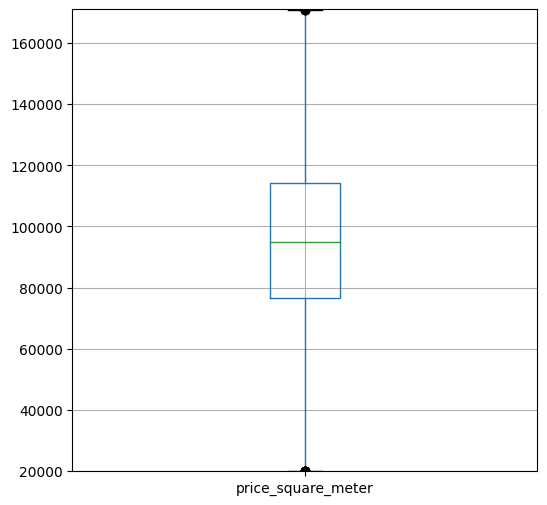

In [59]:
df.boxplot(column='price_square_meter', figsize=(6,6))
plt.ylim(20000, 171000)

    Outliers at the lower limit are up to 20 000 rubles/sq.m. 
    Outliers at the upper limit are from 171 000 rubles to 1 907 500 rubles/sq.m. 
    We will clear the data of outliers.

In [60]:
price_square_meter_data = df.query('20000 < price_square_meter < 171000')

<AxesSubplot:>

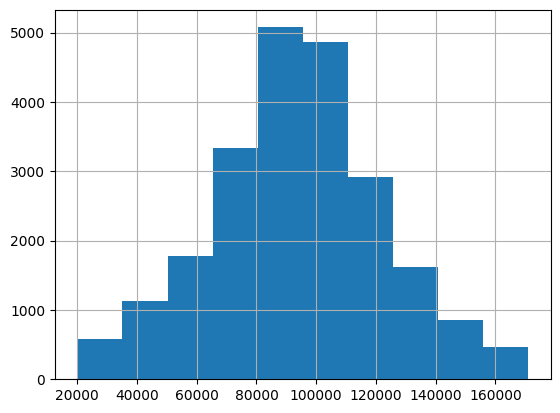

In [61]:
price_square_meter_data['price_square_meter'].hist()

    Normal values ​​without outliers range from 20 000 rubles per square meter 
    to 171 000 rubles per square meter.

    The largest number of apartments range from 80 000 to 110 000 rubles per square meter.
    Let's zoom in on the sample for a closer look.

<AxesSubplot:>

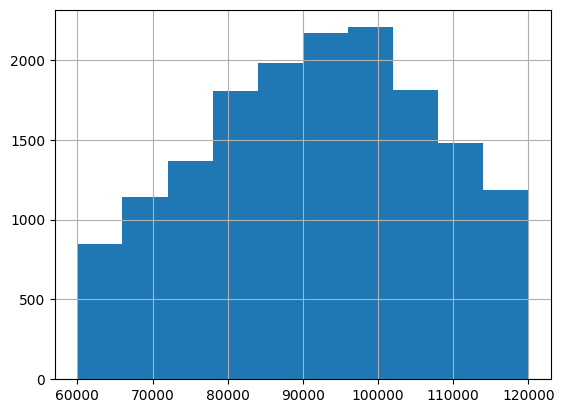

In [62]:
price_square_meter_data[(price_square_meter_data['price_square_meter'] > 60000) & (price_square_meter_data['price_square_meter'] < 120000)]['price_square_meter'].hist() 

    The last graph shows that the largest number of apartments 
    are priced between 90 000 and 100 000 rubles per square meter. 
    This result is confirmed by calling the describe() method. 
    The median is 95 000 rubles per square meter.

### 3.2. Day of Week, Month, and Year of Listing<a class="anchor" id="third-2-bullet"></a>

In [63]:
df['month'] = df['first_day_exposition'].dt.month

In [64]:
df['year'] = df['first_day_exposition'].dt.year

In [65]:
df['weekday'] = df['first_day_exposition'].dt.weekday

In [66]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,ratio_living_total_area,ratio_kitchen_total_area,price_square_meter,month,year,weekday
0,20,13000000,108.0,2019-03-07,3,2.70,16.0,51.00,8,False,False,False,25.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,-1.0,0.472222,0.231481,120370.370370,3,2019,3
1,7,3350000,40.4,2018-12-04,1,2.65,11.0,18.60,1,False,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,0.460396,0.272277,82920.792079,12,2018,1
2,10,5196000,56.0,2015-08-20,2,2.65,5.0,34.30,4,False,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,0.612500,0.148214,92785.714286,8,2015,3
3,0,64900000,159.0,2015-07-24,3,2.65,14.0,90.63,9,False,False,False,27.03,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,NaN,NaN,408176.100629,7,2015,4
4,2,10000000,100.0,2018-06-19,2,3.03,14.0,32.00,13,False,False,False,41.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,0.320000,0.410000,100000.000000,6,2018,1


Text(0.5, 1.0, 'Number of Posted Listings by Months')

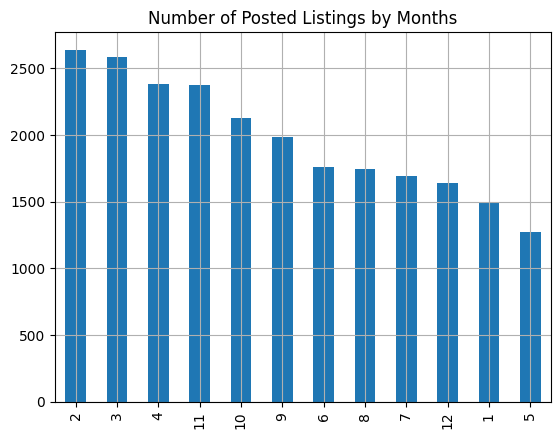

In [67]:
df['month'].value_counts().plot(y='month', kind='bar', grid=True)
plt.title('Number of Posted Listings by Months')

In [68]:
df['month'].value_counts(ascending=False)

2     2640
3     2587
4     2379
11    2371
10    2127
9     1981
6     1760
8     1744
7     1695
12    1641
1     1500
5     1274
Name: month, dtype: int64

    Listings were most often posted in February, March, April, and November.
    The analysis will further examine whether there is a correlation 
    between the month of posting and the apartment's price.

Text(0.5, 1.0, 'Number of Posted Listings by Years')

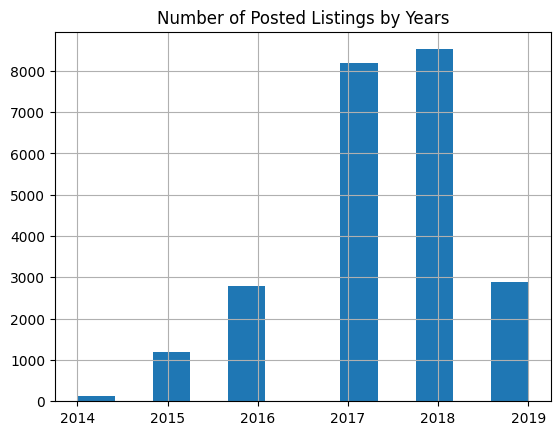

In [69]:
df['year'].hist(bins=12)
plt.title('Number of Posted Listings by Years')

In [70]:
df['year'].value_counts(ascending=False)

2018    8519
2017    8190
2019    2879
2016    2783
2015    1191
2014     137
Name: year, dtype: int64

In [71]:
df['first_day_exposition'].min()

Timestamp('2014-11-27 00:00:00')

In [72]:
df['first_day_exposition'].max()

Timestamp('2019-05-03 00:00:00')

    The largest number of listings were posted in 2018 and 2017.
    These two years accounted for 70.5% of the total number of listings.

    2014, 2015, 2016, and 2019 accounted for only 29.5%.

    It's worth noting that our data for 2014 and 2019 is incomplete.
    Listings for 2014 began on November 27.
    Data for 2019 ends on May 3.

    The analysis will further examine whether there is a correlation 
    between the year of listing and the apartment's price.

Text(0.5, 1.0, 'Number of Posted Listings by Weekdays')

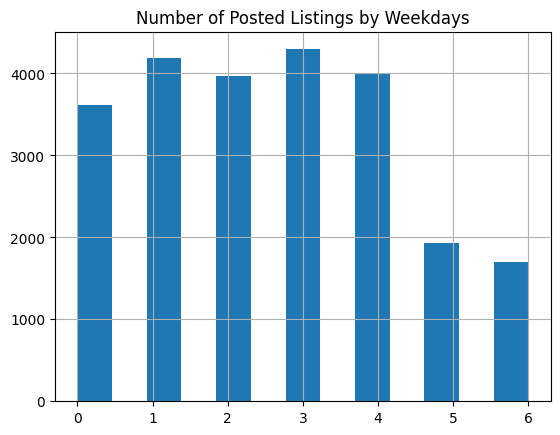

In [73]:
df['weekday'].hist(bins=13)
plt.title('Number of Posted Listings by Weekdays')

In [74]:
df['weekday'].value_counts(ascending=False)

3    4295
1    4183
4    4000
2    3974
0    3612
5    1936
6    1699
Name: weekday, dtype: int64

    The fewest listings are posted on weekends.
    The majority are posted on weekdays.
    Further analysis will examine whether there is a correlation 
    between the day of posting and the apartment's price.

### 3.3. Apartment's Floor Location<a class="anchor" id="third-3-bullet"></a>

In [75]:
def floor_groups(row):
    if row['floor'] == row['floors_total']:
        return 'last'
    if row['floor'] == 1:
        return 'first'
    return 'other'
 
df['floor_groups'] = df.apply(floor_groups, axis=1)

In [76]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,ratio_living_total_area,ratio_kitchen_total_area,price_square_meter,month,year,weekday,floor_groups
0,20,13000000,108.0,2019-03-07,3,2.70,16.0,51.00,8,False,False,False,25.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,-1.0,0.472222,0.231481,120370.370370,3,2019,3,other
1,7,3350000,40.4,2018-12-04,1,2.65,11.0,18.60,1,False,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,0.460396,0.272277,82920.792079,12,2018,1,first
2,10,5196000,56.0,2015-08-20,2,2.65,5.0,34.30,4,False,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,0.612500,0.148214,92785.714286,8,2015,3,other
3,0,64900000,159.0,2015-07-24,3,2.65,14.0,90.63,9,False,False,False,27.03,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,NaN,NaN,408176.100629,7,2015,4,other
4,2,10000000,100.0,2018-06-19,2,3.03,14.0,32.00,13,False,False,False,41.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,0.320000,0.410000,100000.000000,6,2018,1,other


In [77]:
df['floor_groups'].value_counts(ascending=False)

other    17446
last      3361
first     2892
Name: floor_groups, dtype: int64

Text(0.5, 1.0, 'Apartments Number on Different Floor Levels')

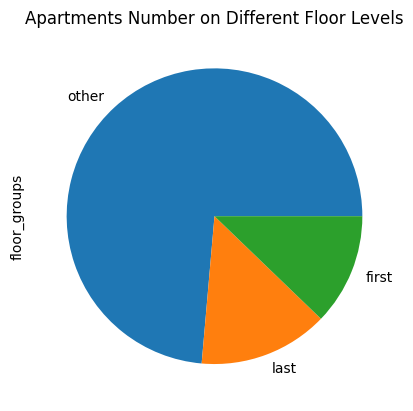

In [78]:
df['floor_groups'].value_counts(ascending=False).plot(y='floor_groups', kind='pie')
plt.title('Apartments Number on Different Floor Levels')

    The smallest number of apartments are located on the ground floor—12.2% of the total sample.

    The top floor accounts for 14.18% of the total sample.

    73.62% of apartments fell into the "other floor" group.

### 3.4. Ratio of Living Space to Total Area / Ratio of Kitchen Area to Total Area<a class="anchor" id="third-4-bullet"></a>

In [79]:
df['ratio_living_total_area'] = df['living_area'] / df['total_area']

In [80]:
df['ratio_kitchen_total_area'] = df['kitchen_area'] / df['total_area']

In [81]:
df.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,ratio_living_total_area,ratio_kitchen_total_area,price_square_meter,month,year,weekday,floor_groups
0,20,13000000,108.0,2019-03-07,3,2.70,16.0,51.00,8,False,False,False,25.00,0.0,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,-1.0,0.472222,0.231481,120370.370370,3,2019,3,other
1,7,3350000,40.4,2018-12-04,1,2.65,11.0,18.60,1,False,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,0.0,0.0,0.0,81.0,0.460396,0.272277,82920.792079,12,2018,1,first
2,10,5196000,56.0,2015-08-20,2,2.65,5.0,34.30,4,False,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0,0.612500,0.148214,92785.714286,8,2015,3,other
3,0,64900000,159.0,2015-07-24,3,2.65,14.0,90.63,9,False,False,False,27.03,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0,0.570000,0.170000,408176.100629,7,2015,4,other
4,2,10000000,100.0,2018-06-19,2,3.03,14.0,32.00,13,False,False,False,41.00,0.0,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0,0.320000,0.410000,100000.000000,6,2018,1,other


In [82]:
df['ratio_living_total_area'].describe()

count    23699.000000
mean         0.565186
std          0.101059
min          0.021583
25%          0.500000
50%          0.570000
75%          0.631579
max          1.000000
Name: ratio_living_total_area, dtype: float64

Text(0.5, 1.0, 'Ratio of Living Space to Total Area')

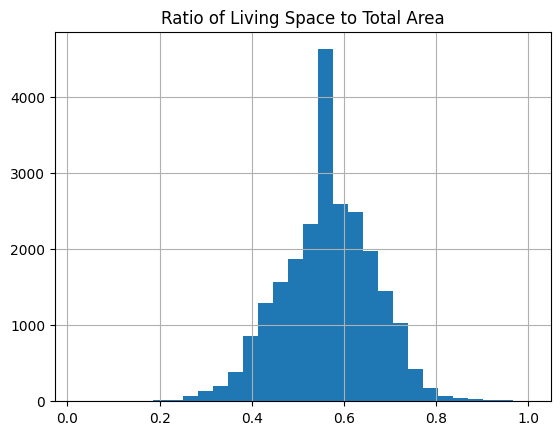

In [83]:
df['ratio_living_total_area'].hist(bins=30)
plt.title('Ratio of Living Space to Total Area')

    According to the graph, most apartments have a living space to total area ratio of 0.57 to 0.58.
    Using the describe() method, we see that the median is 0.57.

In [84]:
df['ratio_kitchen_total_area'].describe()

count    23699.000000
mean         0.185687
std          0.069561
min          0.025381
25%          0.136859
50%          0.170000
75%          0.223717
max          0.787879
Name: ratio_kitchen_total_area, dtype: float64

Text(0.5, 1.0, 'Ratio of Kitchen Area to Total Area')

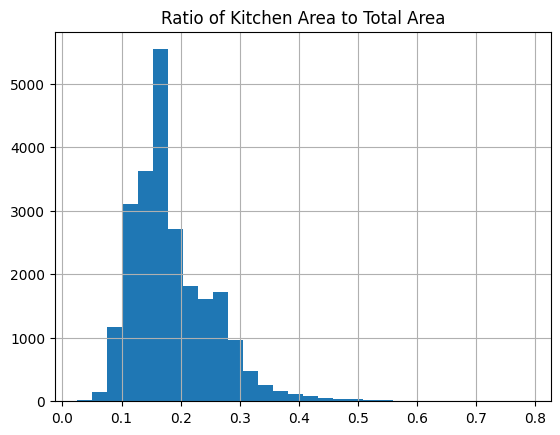

In [85]:
df['ratio_kitchen_total_area'].hist(bins=30)
plt.title('Ratio of Kitchen Area to Total Area')

    According to the graph, most apartments have a kitchen area to total area 
    ratio of 0.16 to 0.18. Using the describe() method, we see that the median is 0.17.

### Step 4. Exploratory Data Analysis<a class="anchor" id="thourth-bullet"></a>

### 4.1.1. Parameter: Area<a class="anchor" id="thourth-1-1-bullet"></a>

In [86]:
df['total_area'].describe()

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64

    Let's construct a boxplot to determine the range of normal values
    ​​and where the outliers lie.

(11.0, 115.0)

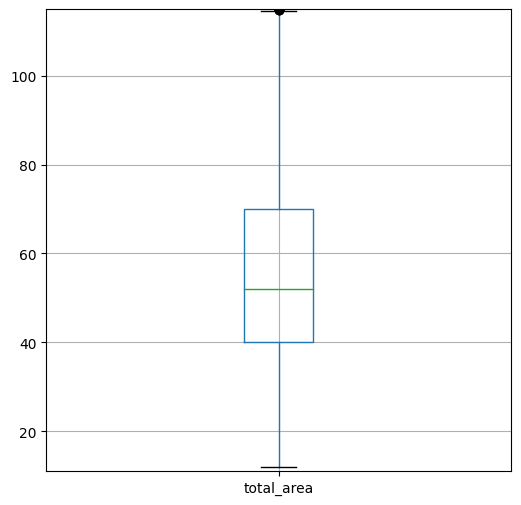

In [87]:
df.boxplot(column='total_area', figsize=(6,6))
plt.ylim(11, 115)

    Normal values ​​fall within the "whiskers," while outliers are found outside the "whiskers".
    Right whisker: outliers start at 115 square meters. The largest outlier is 900 square meters.
    Left whisker: outliers up to 11 square meters.

Text(0.5, 1.0, 'Apartments Area')

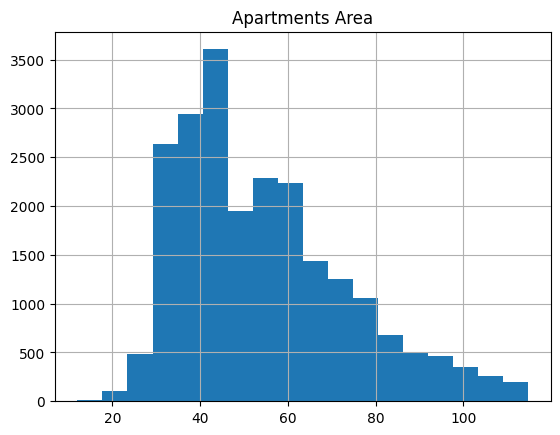

In [88]:
df[(df['total_area'] > 11) & (df['total_area'] < 115)]['total_area'].hist(bins=18)
plt.title('Apartments Area')

    The graph shows that the largest number of apartments are between 40 and 45 square meters.
    Judging by the area, these should be one-bedroom apartments.

    The next most numerous are apartments between 35 and 40 square meters.

    Then come apartments between 30 and 35 square meters.


### 4.1.2. Parameter: Price<a class="anchor" id="thourth-1-2-bullet"></a>

In [89]:
df['last_price'].describe().round()

count        23699.0
mean       6541549.0
std       10887013.0
min          12190.0
25%        3400000.0
50%        4650000.0
75%        6800000.0
max      763000000.0
Name: last_price, dtype: float64

    Let's construct a boxplot to determine the range of normal values
    ​​and where the outliers lie.

(-200000.0, 12000000.0)

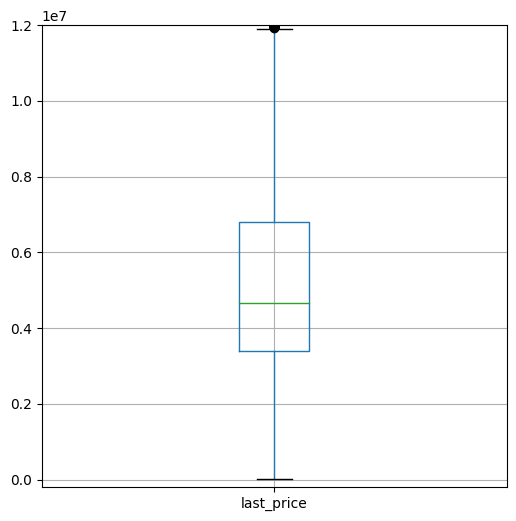

In [90]:
df.boxplot(column='last_price', figsize=(6,6))
plt.ylim(-200000, 12000000)

    The largest outlier is 763 million rubles.
    Outliers start at 12 million rubles.
    Let's plot a histogram with values ​​up to 12 million rubles.

Text(0.5, 1.0, 'The Price of the Apartment at the Time of the Publication Removal')

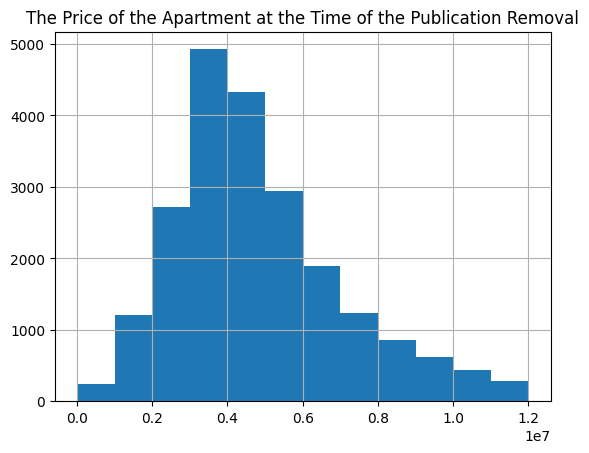

In [91]:
df.query('last_price < 12000000')['last_price'].hist(bins=12)
plt.title('The Price of the Apartment at the Time of the Publication Removal')

    Apartments priced between 3 million and 4 million rubles are in first place by quantity.
    Second place goes to apartments priced between 4 million and 5 million rubles.
    And third place goes to apartments priced between 5 million and 6 million rubles.

    The minimum price is 12 190 rubles. An apartment can't cost that much. The minimum price
    in the Leningrad Region is studios starting from 1 million rubles. Let's look at this section of the table.

<AxesSubplot:>

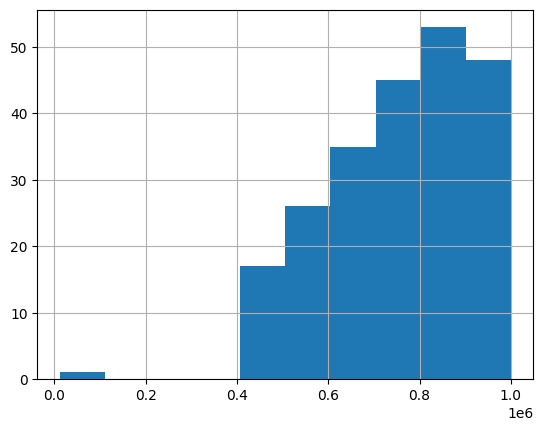

In [92]:
df.query('last_price < 1000000')['last_price'].hist()

In [93]:
len(df[(df['last_price']<1000000)]) / len(df)

0.009494071479809275

In [94]:
min_last_price = df[df['last_price'] < 1000000]
len(min_last_price)

225

    A total of 225 apartments priced under 1 million rubles, 
    representing 0.94% of the total sample. 
    We will also consider these to be rare and outliers.

### 4.1.3. Parameter: Number of Rooms<a class="anchor" id="thourth-1-3-bullet"></a>

In [95]:
df['rooms'].value_counts()

1     8047
2     7940
3     5814
4     1180
5      326
0      197
6      105
7       59
8       12
9        8
10       3
11       2
14       2
19       1
16       1
12       1
15       1
Name: rooms, dtype: int64

    Some apartments have 0 rooms, which is impossible. If it's a studio apartment,
    we'll assume it has 1 room. Because a studio apartment is a
    one-room living space with no walls or partitions separating
    the sleeping area from the kitchen and living room. Let's replace all zero values ​​with 1.

In [96]:
df['rooms'] = df['rooms'].replace(0, 1)

(0.0, 6.5)

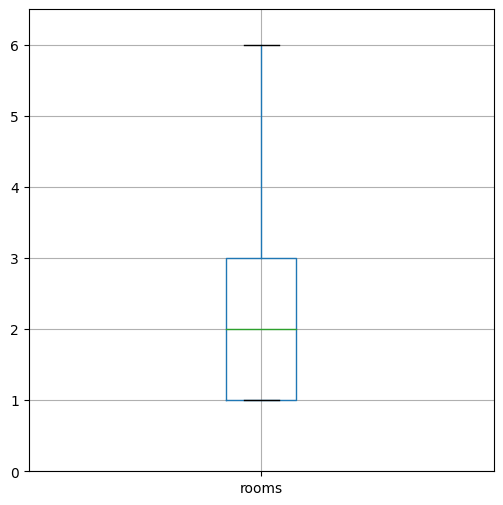

In [97]:
df.boxplot(column='rooms', figsize=(6,6))
plt.ylim(0, 6.5)

    According to the boxplot, the outliers are apartments with more than 6 rooms.
    Let's see what proportion of the sample consists of apartments with 7 or more rooms.

In [98]:
len(df[(df['rooms']>7)]) / len(df)

0.0013080720705515002

In [99]:
many_rooms = df[df['rooms'] > 7]
len(many_rooms)

31

    There are only 31 apartments with 7 or more rooms, 
    which is 0.13% of the total sample.
    Let's look at the histogram without the rare values.

Text(0.5, 1.0, 'Number of Rooms in Apartments')

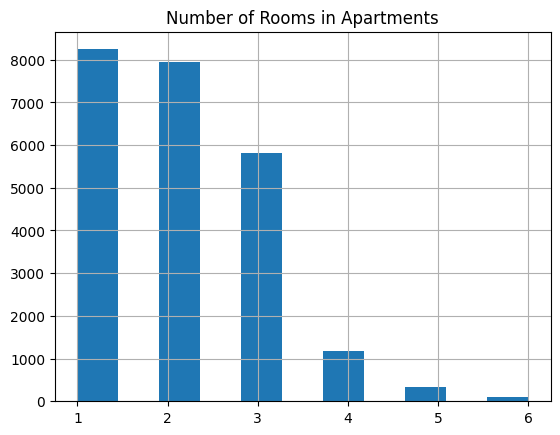

In [100]:
df.query('rooms < 7')['rooms'].hist(bins=11)
plt.title('Number of Rooms in Apartments')

    The sample consists primarily of one-bedroom apartments (along with studio apartments).
    Two-bedroom apartments come in second.

### 4.1.4. Parameter: Ceiling Height<a class="anchor" id="thourth-1-4-bullet"></a>

In [101]:
df['ceiling_height'].describe().round(2)

count    23699.00
mean         2.72
std          0.99
min          1.00
25%          2.60
50%          2.65
75%          2.70
max        100.00
Name: ceiling_height, dtype: float64

(2.4, 2.9)

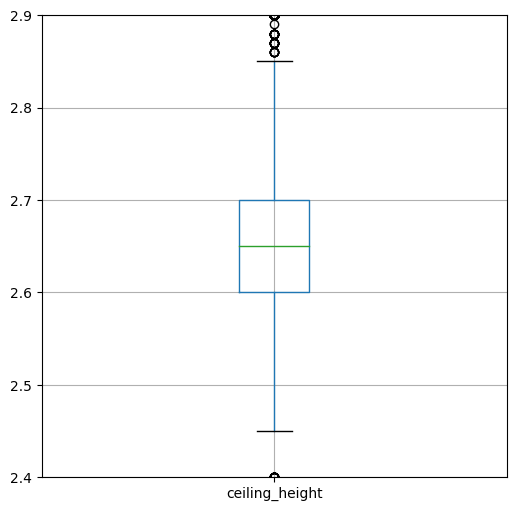

In [102]:
df.boxplot(column='ceiling_height', figsize=(6,6))
plt.ylim(2.4, 2.9)

    The largest outlier is a ceiling height of 100 meters.
    The remaining outliers range from 2.9 to 30 meters. Let's look at the histogram
    with ceiling heights up to 2.9 meters.

Text(0.5, 1.0, 'Ceiling Height')

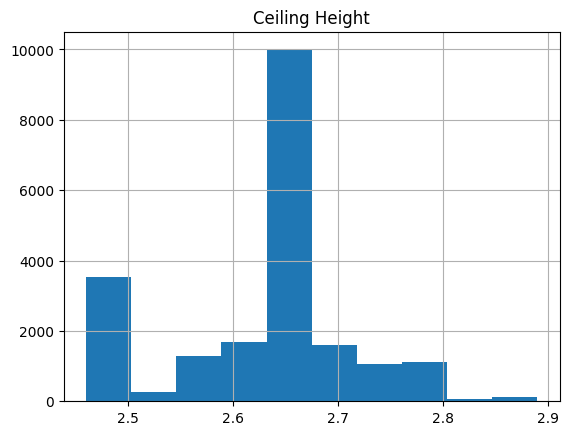

In [103]:
df.query('2.45 < ceiling_height < 2.9')['ceiling_height'].hist(bins=10)
plt.title('Ceiling Height')

Most apartments have ceilings in the range of 2.6 to 2.7 meters

### 4.1.5. Parameter: Time to Sell an Apartment<a class="anchor" id="thourth-1-5-bullet"></a>

In [104]:
df['days_exposition'].describe()

count    23699.000000
mean       156.474619
std        213.645563
min         -1.000000
25%         22.000000
50%         74.000000
75%        199.000000
max       1580.000000
Name: days_exposition, dtype: float64

    The median is 74 days, and the mean is 156 days. 
    Since these two values ​​differ significantly, 
    there are many outliers in the data that need to be identified.

(-10.0, 465.0)

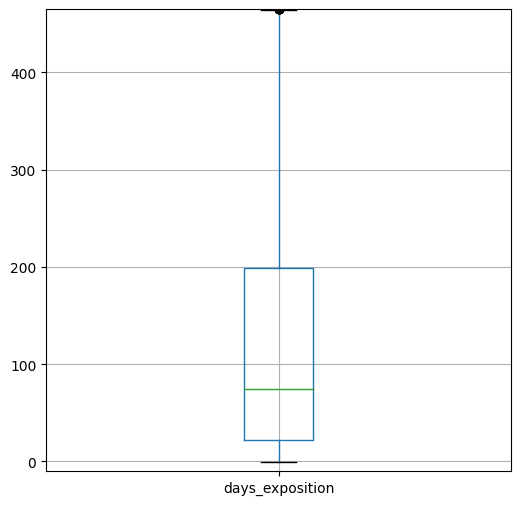

In [105]:
df.boxplot(column='days_exposition', figsize=(6,6))
plt.ylim(-10, 465)

    Outliers begin beyond 465 days. At the very beginning, 
    We replaced missing values ​​with "-1" to easily identify 
    unclosed trades in the data and charts.
    Let's view the cross-section from 0 to 465 days.

Text(0.5, 1.0, "Number of Days from the Publication to Listing's Removal")

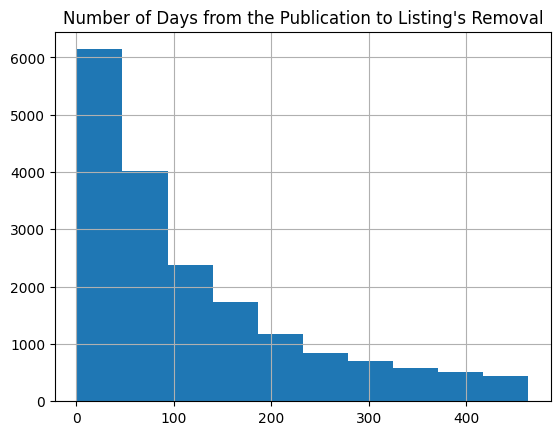

In [106]:
df.query('-1 < days_exposition < 465')['days_exposition'].hist(bins=10)
plt.title('''Number of Days from the Publication to Listing's Removal''')

    The majority of transactions take place in the first 90 days.

Text(0.5, 1.0, "Number of Days from the Publication to Listing's Removal")

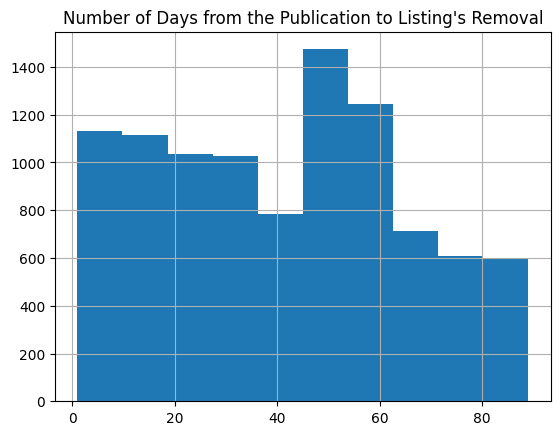

In [107]:
df.query('-1 < days_exposition < 90')['days_exposition'].hist(bins=10)
plt.title('''Number of Days from the Publication to Listing's Removal''')

    Let's take a closer look at the first 5 days and the peak sales period from 40 to 65 days.

<AxesSubplot:>

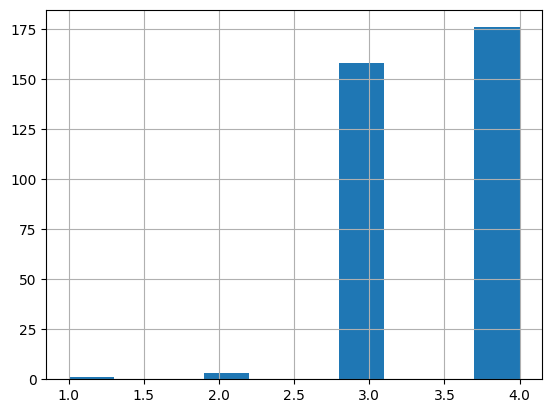

In [108]:
df.query('-1 < days_exposition < 5')['days_exposition'].hist(bins=10)

    There are almost no sales in the first two days, and the data appears sparse and abnormal.

<AxesSubplot:>

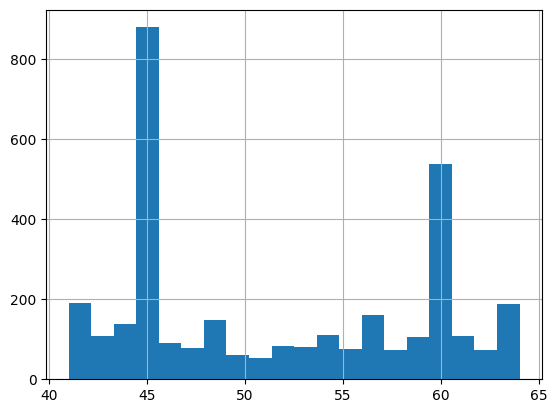

In [109]:
df.query('40 < days_exposition < 65')['days_exposition'].hist(bins=20)

    The highest number of closed deals occurs on the 45th day after listing.
    The second peak occurs on the 60th day.

    Sales can be considered fast if they close within 25 days (25% quartile - 22 days).
    Sales can be considered long-term if they take longer 
    than 120 days to close (75% quartile - 199 days).
    
    Most deals close between 45 and 60 days.

### 4.2. Factors Affecting Apartment Price<a class="anchor" id="thourth-2-bullet"></a>

### 4.2.1. Price per Square Meter as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-1-bullet"></a>

    Previously, outliers were identified for the cost per square meter data 
    and for the price at the time of publication's removal data. 
    When analyzing the factors affecting apartment prices, data without outliers is used.

<AxesSubplot:xlabel='price_square_meter', ylabel='last_price'>

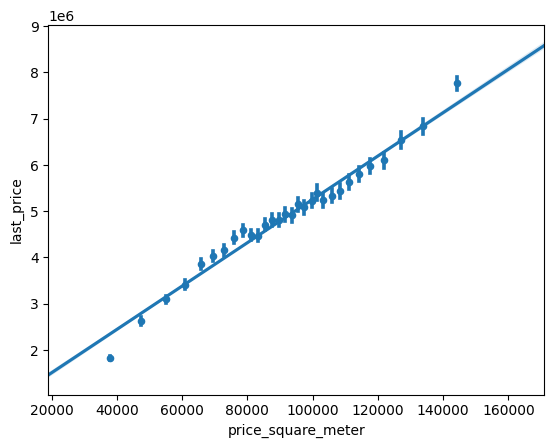

In [110]:
price_per_meter_table = df.query('19000 < price_square_meter < 171000 and 1000000 < last_price < 12000000')
import seaborn as sns
sns.regplot(x='price_square_meter', y='last_price',data=price_per_meter_table, x_bins=30, scatter_kws={'s':20})

    The graph shows a relationship: as the first value (the price per square meter) increases, 
    the second value (the apartment price) increases. 
    That is, the higher the price per square meter, the higher the apartment price.

In [111]:
df['price_square_meter'].corr(df['last_price'])

0.7364988054723017

    The Pearson coefficient is 0.7.
    The closer the Pearson coefficient is to 1, the stronger the relationship.

### 4.2.2. Number of Rooms in an Apartment as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-2-bullet"></a>

In [112]:
room_data = df.query('rooms < 7 and 1000000 < last_price < 12000000')

<AxesSubplot:xlabel='rooms', ylabel='last_price'>

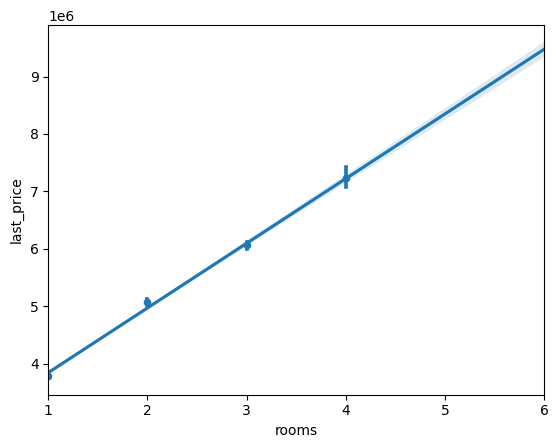

In [113]:
sns.regplot(x='rooms', y='last_price',data=room_data, x_bins=30, scatter_kws={'s':20})

In [114]:
df_cor_rooms = df.query('rooms < 7') 
df_cor_rooms = df_cor_rooms.pivot_table(index='rooms', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
df_cor_rooms.columns=['rooms', 'quantity_of_apartments', 'average_apartment_price']
df_cor_rooms

,rooms,quantity_of_apartments,average_apartment_price
0,6,105,19000000
1,5,326,14000000
2,4,1180,9000000
3,3,5814,6200000
4,2,7940,4770169
5,1,8244,3585000


In [115]:
df['rooms'].corr(df['last_price']).round(2)

0.37

    The graph shows the relationship between apartment price and the number of rooms in it.
    As the number of rooms in an apartment increases, the price increases.
    We see the same strong relationship in the table when grouping the data by the number
    of rooms and calculating the average apartment price.

    The Pearson coefficient is 0.37. This coefficient can be influenced by other factors.
    For example, the location of the apartment. A one-room apartment in the city center
    in an elite building will cost more than a two-room apartment in a small village
    in the Leningrad region.

### 4.2.3. Distance from the Center as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-3-bullet"></a>

In [116]:
df['cityCenters_nearest'].describe()

count    18180.000000
mean     14191.277833
std       8608.386210
min        181.000000
25%       9238.000000
50%      13098.500000
75%      16293.000000
max      65968.000000
Name: cityCenters_nearest, dtype: float64

    Let's identify outliers

(-100.0, 27100.0)

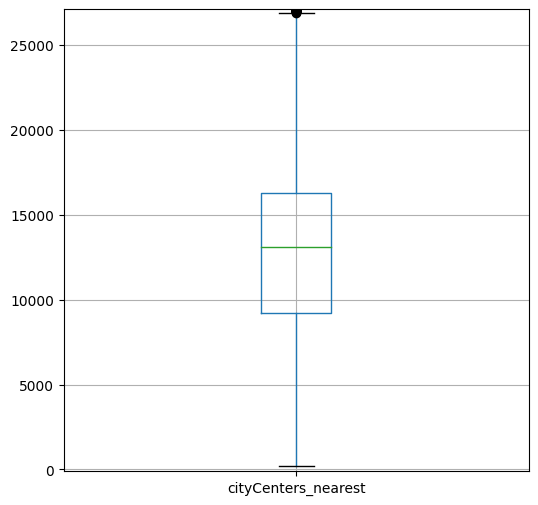

In [117]:
df.boxplot(column='cityCenters_nearest', figsize=(6,6))
plt.ylim(-100, 27100)

In [118]:
city_сenter_data = df.query('cityCenters_nearest < 27100 and 1000000 < last_price < 12000000')

<AxesSubplot:xlabel='cityCenters_nearest', ylabel='last_price'>

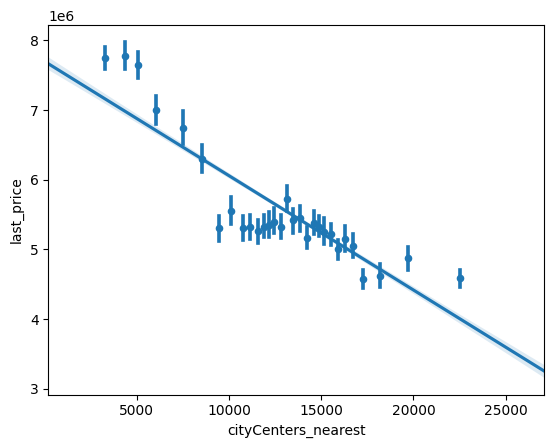

In [119]:
sns.regplot(x='cityCenters_nearest', y='last_price',data=city_сenter_data, x_bins=30, scatter_kws={'s':20})

In [120]:
df['cityCenters_nearest'].corr(df['last_price'])

-0.20674734874298376

    The graph shows the relationship between the apartment's location:
    - the closer the apartment is to the city center, the more expensive it is
    - the further the apartment is from the city center, the cheaper it is

    The Pearson coefficient is negative; an increase in the "distance from the city center" value
    is associated with a decrease in the "apartment price" value

### 4.2.4. Apartment Floor as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-4-bullet"></a>

Text(0.5, 1.0, "Apartment's Cost at Different Floor Levels")

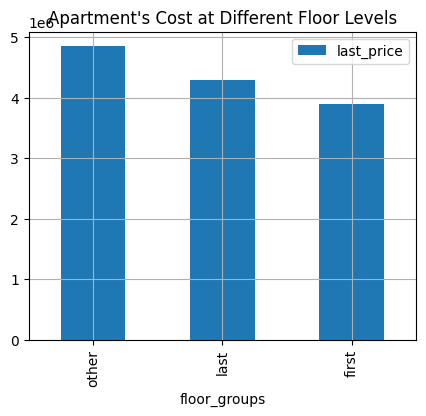

In [121]:
df.pivot_table(index='floor_groups', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(5, 4))
plt.title('''Apartment's Cost at Different Floor Levels''')

In [122]:
df_floor = df.pivot_table(index='floor_groups', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
df_floor.columns = ['floor', 'quantity_of_apartments', 'average_apartment_price']
df_floor

,floor,quantity_of_apartments,average_apartment_price
0,other,17446,4850000
1,last,3361,4300000
2,first,2892,3900000


    Looking at the graph and table, the highest prices are 
    for apartments on the "other" floor (median 4.85 million rubles).
    The lowest prices are for apartments on the first floor (median 3.9 million rubles).
    The median for the "top floor" group is 4.3 million.

### 4.2.5. Day of the Week as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-5-bullet"></a>

Text(0.5, 1.0, 'Apartment Prices on Different Weekdays')

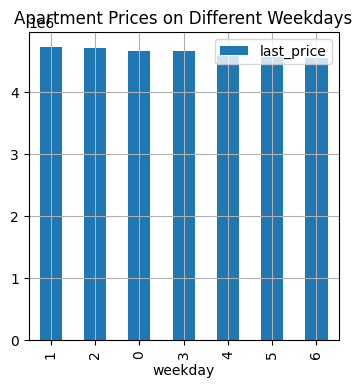

In [123]:
df.pivot_table(index='weekday', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(4, 4))
plt.title('Apartment Prices on Different Weekdays')

In [124]:
df_weekday = df.pivot_table(index='weekday', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
df_weekday.columns = ['weekday', 'quantity_of_apartments', 'average_apartment_price']
df_weekday

,weekday,quantity_of_apartments,average_apartment_price
0,1,4183,4730000
1,2,3974,4700000
2,0,3612,4650000
3,3,4295,4650000
4,4,4000,4585000
5,5,1936,4555000
6,6,1699,4550000


    Neither the graph nor the grouping of data by day of the week 
    with median calculations showed a correlation between 
    the apartment price and the day the ad was posted.
    This factor does not affect the apartment price.

### 4.2.6 Month as a Factor Affecting Apartment Price<a class="anchor" id="thourth-2-6-bullet"></a>

Text(0.5, 1.0, 'Apartment Prices by Months')

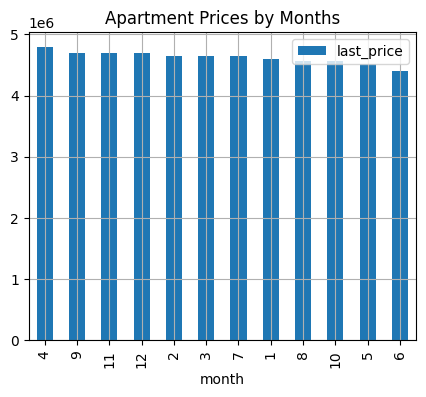

In [125]:
df.pivot_table(index='month', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(5, 4))
plt.title('Apartment Prices by Months')

In [126]:
df_month = df.pivot_table(index='month', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
df_month.columns = ['month', 'qty_of_apartments', 'avg_apartment_price']
df_month

,month,qty_of_apartments,avg_apartment_price
0,4,2379,4800000
1,9,1981,4700000
2,11,2371,4700000
3,12,1641,4700000
4,2,2640,4650000
5,3,2587,4650000
6,7,1695,4650000
7,1,1500,4600000
8,8,1744,4570000
9,10,2127,4570000


    The month in which the most expensive apartment listings were posted was April.
    September, October, and November were in second place (the same price).
    February, March, and July were in third place (the same price).

    The prices differed little by month. 
    The April median differed from the June median (the lowest apartment price) by only 8.3%.

    Neither the graph nor the grouping of the data by month with the median calculations 
    showed a correlation between the apartment price and the month the listing was posted.
    This factor did not affect the apartment price.

### 4.2.7. Year as a Factor Influencing Apartment Price<a class="anchor" id="thourth-2-7-bullet"></a>

Text(0.5, 1.0, 'Apartment Prices by Years')

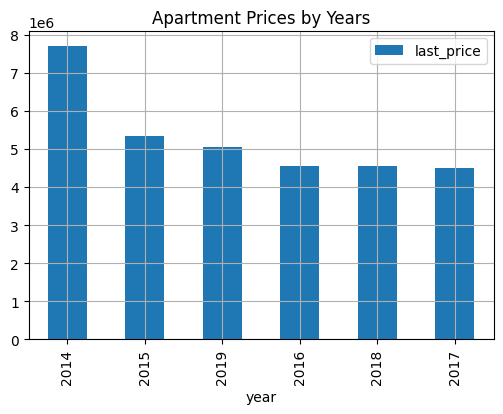

In [127]:
df.pivot_table(index='year', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Apartment Prices by Years')

In [128]:
df_year = df.pivot_table(index='year', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
df_year.columns = ['year','qty_of_apartments', 'avg_apartment_price']
df_year

,year,qty_of_apartments,avg_apartment_price
0,2014,137,7700000
1,2015,1191,5350000
2,2019,2879,5050000
3,2016,2783,4550000
4,2018,8519,4550000
5,2017,8190,4500000


    Both the graph and the yearly data grouping with median calculations showed 
    that 2014 saw the highest-priced apartment listings. 
    This can be linked to the country's economic situation. 
    In the fourth quarter of 2014, Russia experienced a
    currency crisis (a sharp weakening of the Russian ruble against foreign currencies).
    The purchasing power of the population decreased.

    At the beginning of the analysis, it was discovered that there were 
    only 137 listings for 2014, representing 0.59% of the total sample. 
    Listings for 2014 began to be recorded on November 27th.
    There could be several reasons for this:
    
    1. The service began operating at the end of 2014.
    2. Data for 2014 was lost or downloaded incorrectly.

    In any case, 0.59% is too small a sample to draw conclusions
    for the entire year.

    In second place and third place in 2015 and 2019, respectively

### 4.3. 10 Towns with the Largest Number of Listings<a class="anchor" id="thourth-3-bullet"></a>

In [129]:
df['locality_name'].value_counts(ascending=False).head(10)

Санкт-Петербург      15721
посёлок Мурино         522
посёлок Шушары         440
Всеволожск             398
Пушкин                 369
Колпино                338
посёлок Парголово      327
Гатчина                307
деревня Кудрово        299
Выборг                 237
Name: locality_name, dtype: int64

In [130]:
ten_locality_name = ['Санкт-Петербург', 'посёлок Мурино', 'посёлок Шушары', 'Всеволожск',
                     'Пушкин', 'Колпино', 'посёлок Парголово', 'Гатчина', 'деревня Кудрово',
                     'Выборг']

In [131]:
ten_locality_name_data = df.query('locality_name in @ten_locality_name')

**Average price per square meter in 10 settlements:**

In [132]:
ten_locality_name_data['price_square_meter'].mean().round()

109073.0

In [133]:
ten_loc_name = ten_locality_name_data.groupby('locality_name')['last_price'].agg(['count', 'median']).sort_values('median',ascending=False).reset_index()
ten_loc_name.columns = ['locality_name', 'qty_of_apartments', 'avg_apartment_price']
ten_loc_name

,locality_name,qty_of_apartments,avg_apartment_price
0,Санкт-Петербург,15721,5500000
1,Пушкин,369,5180000
2,посёлок Парголово,327,4100000
3,посёлок Шушары,440,3950000
4,деревня Кудрово,299,3790000
5,Колпино,338,3600000
6,Всеволожск,398,3450000
7,посёлок Мурино,522,3400000
8,Гатчина,307,3100000
9,Выборг,237,2897000


Text(0.5, 1.0, 'The Cost of Apartments in Different Localities')

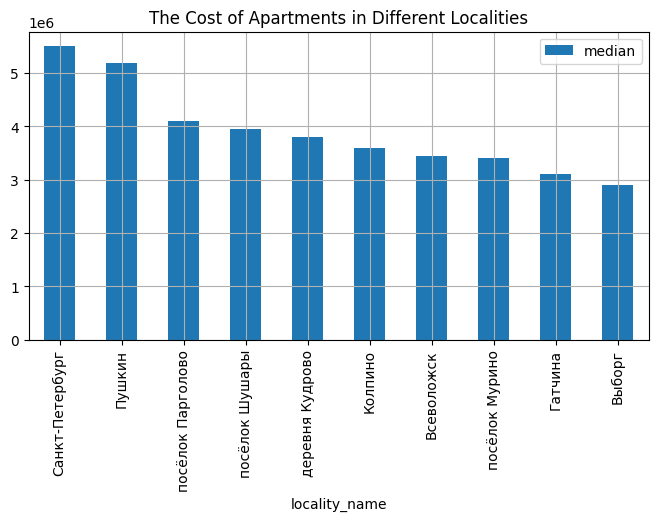

In [134]:
ten_locality_name_data.groupby('locality_name')['last_price'].agg(['median']).sort_values('median',ascending=False).plot(kind='bar', grid=True, figsize=(8, 4))
plt.title('The Cost of Apartments in Different Localities')

    The towns with the highest housing costs are St. Petersburg and Pushkin.
    The town with the lowest housing costs is Vyborg.

### 4.4. Housing Analysis in the Center of St. Petersburg<a class="anchor" id="thourth-4-bullet"></a>

### 4.4.1. Price Dependence on Distance to the Center (St. Petersburg)<a class="anchor" id="thourth-4-1-bullet"></a>

In [135]:
spb = df.query('"Санкт-Петербург" in locality_name')

In [136]:
pd.set_option('mode.chained_assignment', None)
spb['center_km'] = spb['cityCenters_nearest'] / 1000 

In [137]:
spb['center_km'] = round(spb['center_km'])

In [138]:
spb['center_km'].describe()

count    15660.000000
mean        11.596041
std          4.863594
min          0.000000
25%          8.000000
50%         12.000000
75%         15.000000
max         29.000000
Name: center_km, dtype: float64

    Let's find outliers for the ['last_price'] column for the center of St. Petersburg,
    to correctly calculate the average price for each kilometer

(-150000.0, 14100000.0)

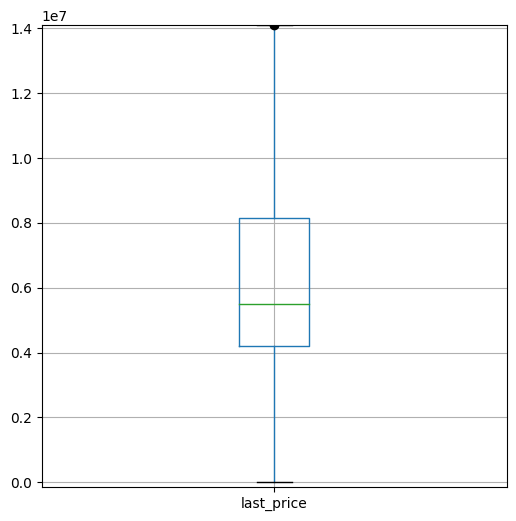

In [139]:
spb.boxplot(column='last_price', figsize=(6,6))
plt.ylim(-150000, 14100000)

In [140]:
spb_good_data = spb.query('last_price < 14100000')

In [141]:
spb['price_per_meter'] = spb['last_price'] / spb['total_area']
spb['price_per_meter'] = spb['price_per_meter'].round(1)

In [142]:
spb_km_price = spb.groupby('center_km')['last_price'].agg(['count', 'median']).sort_values('median',ascending=False).reset_index()
spb_km_price.columns = ['center_km','qty_of_apartments', 'avg_apartment_price']
spb_km_price.head(10)

,center_km,qty_of_apartments,avg_apartment_price
0,0.0,27,17900000
1,1.0,192,11395000
2,2.0,310,10000000
3,5.0,920,9500000
4,4.0,688,9200000
5,6.0,618,8900000
6,3.0,350,8409000
7,27.0,2,8300000
8,7.0,420,7800000
9,8.0,597,7450000


Text(0.5, 1.0, 'Apartment Prices by Kilometers from the City Center')

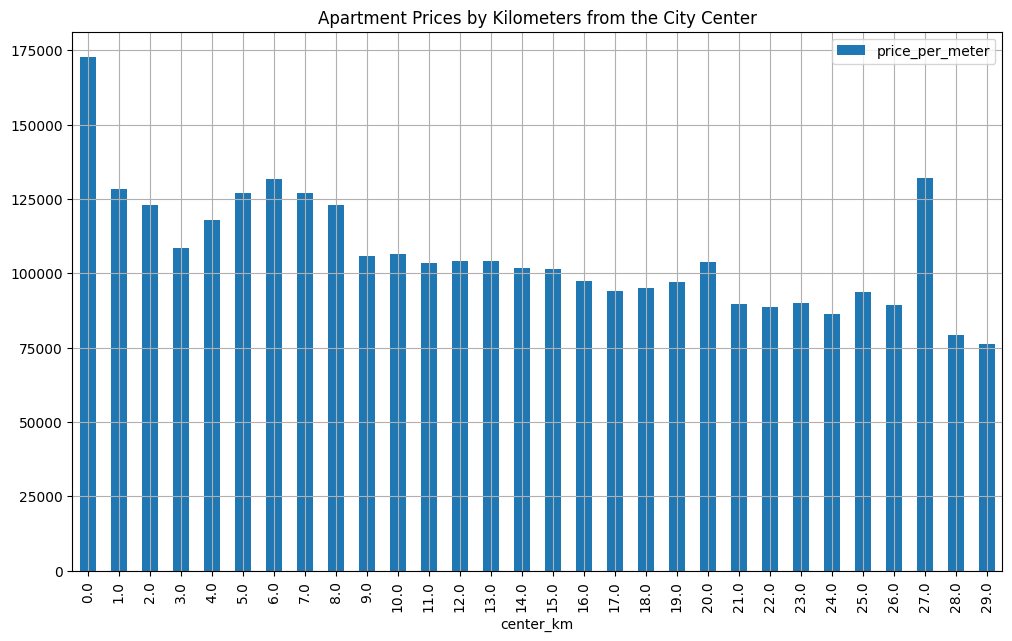

In [143]:
spb.pivot_table(index='center_km', values='price_per_meter', aggfunc=('median')).plot(kind='bar', grid=True, figsize=(12, 7))
plt.title('Apartment Prices by Kilometers from the City Center')

    We'll consider the center to be between 0 km and 3 km.
    Maximum prices are between 0 and 8 km.
    Outliers are 27 km from the center.

### 4.4.2. Area (Apartments in the Center of St. Petersburg)<a class="anchor" id="thourth-4-2-bullet"></a>

In [144]:
spb_center = spb_good_data.query('center_km < 3')

In [145]:
spb_center['total_area'].describe()

count    354.000000
mean      79.857684
std       29.872939
min       12.000000
25%       60.000000
50%       75.900000
75%       96.000000
max      206.000000
Name: total_area, dtype: float64

(10.0, 152.0)

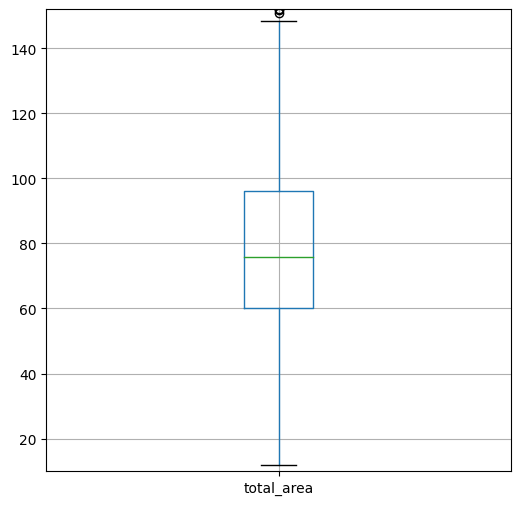

In [146]:
spb_center.boxplot(column='total_area', figsize=(6,6))
plt.ylim(10, 152)


Text(0.5, 1.0, 'Apartment Area in the Center of St. Petersburg')

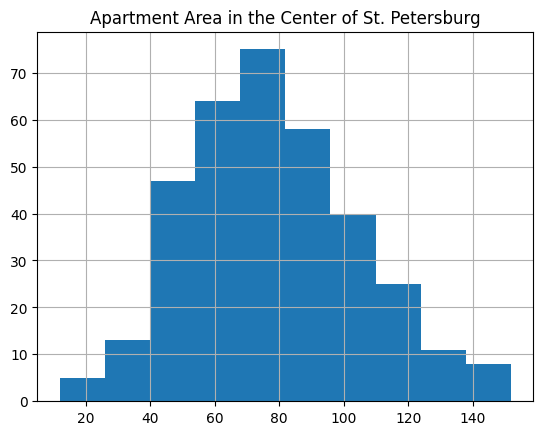

In [147]:
spb_center.query('10 < total_area < 152.0')['total_area'].hist(bins=10)
plt.title('Apartment Area in the Center of St. Petersburg')

       We see three groups.
    1. In first place are apartments with an area of ​​70-80 square meters.
    2. In second place are apartments with an area of ​​55-70 square meters.
    3. In third place are apartments with an area of ​​80-90 square meters.

### 4.4.3. Price (Apartments in the Center of St. Petersburg)<a class="anchor" id="thourth-4-3-bullet"></a>

In [148]:
spb_center['last_price'].describe().round()

count         354.0
mean      8908630.0
std       2651770.0
min       2100000.0
25%       7000000.0
50%       8800000.0
75%      10752500.0
max      14050000.0
Name: last_price, dtype: float64

(2000000.0, 14550000.0)

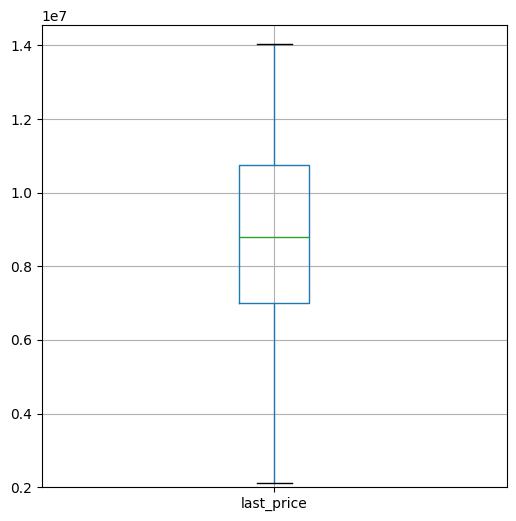

In [149]:
spb_center.boxplot(column='last_price', figsize=(6,6))
plt.ylim(2000000, 14550000)

<AxesSubplot:>

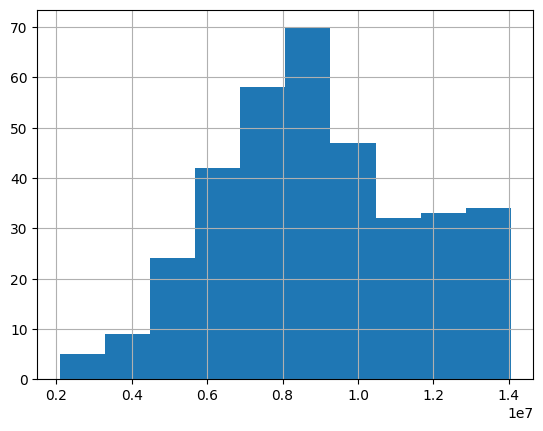

In [150]:
spb_center.query('2000000 < last_price < 14550000')['last_price'].hist(bins=10)

    In the center of St. Petersburg, the most common apartment price is from 8.5 to 9 million rubles.

### 4.4.4. Number of Rooms (Apartments in the Center of St. Petersburg)<a class="anchor" id="thourth-4-4-bullet"></a>

In [151]:
spb_center['rooms'].describe()

count    354.000000
mean       2.807910
std        1.099753
min        1.000000
25%        2.000000
50%        3.000000
75%        3.750000
max        7.000000
Name: rooms, dtype: float64

(0.0, 7.0)

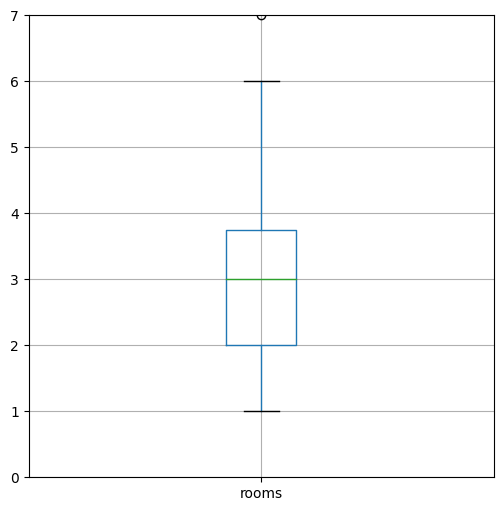

In [152]:
spb_center.boxplot(column='rooms', figsize=(6,6))
plt.ylim(0, 7)

Text(0.5, 1.0, 'Number of Rooms in Apartments (Center of St. Petersburg)')

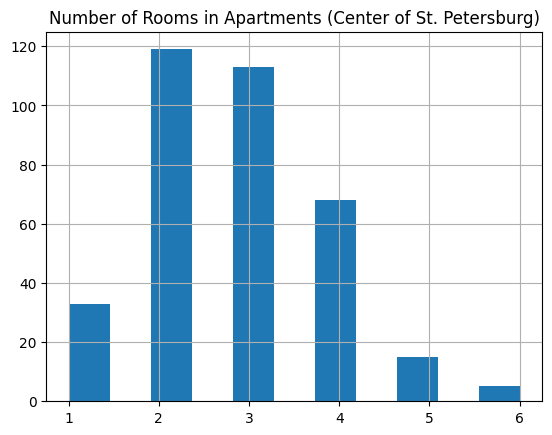

In [153]:
spb_center.query('rooms < 7')['rooms'].hist(bins=11)
plt.title('Number of Rooms in Apartments (Center of St. Petersburg)')

In [154]:
spb_center['rooms'].value_counts(ascending=False)

2    119
3    113
4     68
1     33
5     15
6      5
7      1
Name: rooms, dtype: int64

    In central St. Petersburg, there were more listings for two-room apartments.
    Three-room apartments were in second place.
    There was only one listing for a seven-room apartment.

### 4.4.5. Ceiling Height (Apartments in the Center of St. Petersburg)<a class="anchor" id="thourth-4-5-bullet"></a>

In [155]:
spb_center['ceiling_height'].describe()

count    354.000000
mean       3.012486
std        0.411140
min        2.500000
25%        2.650000
50%        2.980000
75%        3.250000
max        5.800000
Name: ceiling_height, dtype: float64

(2.45, 4.1)

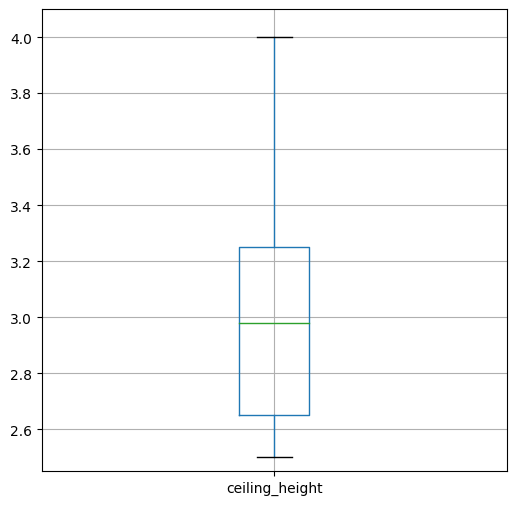

In [156]:
spb_center.boxplot(column='ceiling_height', figsize=(6,6))
plt.ylim(2.45, 4.1)

Text(0.5, 1.0, 'Ceiling Height in the Center of St. Petersburg')

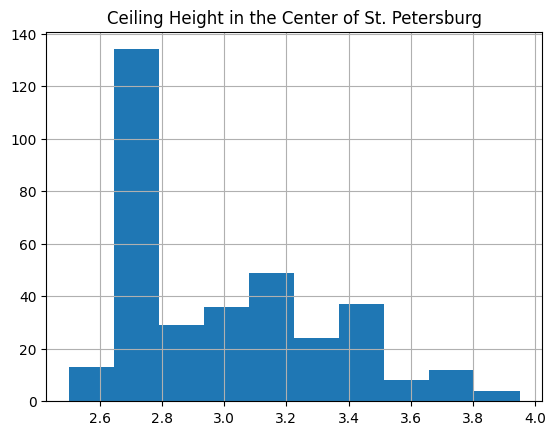

In [157]:
spb_center.query('2.45 < ceiling_height < 4.0')['ceiling_height'].hist()
plt.title('Ceiling Height in the Center of St. Petersburg')

Ceiling height is the same as in the main sample: 2.7 - 2.8 m

### 4.4.6. Factors Affecting the Price of an Apartment (Center of St. Petersburg)<a class="anchor" id="thourth-4-6-bullet"></a>

**Number of Rooms**

<AxesSubplot:xlabel='rooms', ylabel='last_price'>

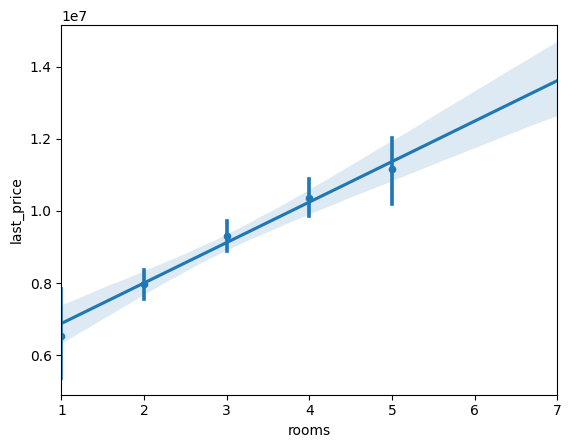

In [158]:
sns.regplot(x='rooms', y='last_price',data=spb_center, x_bins=30, scatter_kws={'s':20})

In [159]:
six_rooms = spb_center.query('rooms < 7') 
six_rooms = six_rooms.pivot_table(index='rooms', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
six_rooms.columns = ['rooms', 'quantity_of_apartments', 'average_apartment_price']
six_rooms

,rooms,quantity_of_apartments,average_apartment_price
0,6,5,11700000
1,5,15,10900000
2,4,68,9925000
3,3,113,8900000
4,2,119,7500000
5,1,33,5200000


In [160]:
spb_center['rooms'].corr(spb_center['last_price']).round(2)

0.47

    The graph shows the relationship between apartment price and the number of rooms in it. 
    As the number of rooms in an apartment increases, the price increases. 
    We see the same strong relationship when grouping
    the data by the number of rooms and calculating the median. 
    The Pearson coefficient is 0.45. This coefficient can be influenced by other factors, 
    such as the apartment's location (the closer to the center, the more expensive), the luxury
    of the building, the floor, etc.

**Floor**

In [161]:
spb_floors = spb_center.pivot_table(index='floor_groups', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False).reset_index()
spb_floors.columns = ['floor', 'quantity_of_apartments', 'average_apartment_price']
spb_floors

,floor,quantity_of_apartments,average_apartment_price
0,other,203,9200000
1,last,94,8800000
2,first,57,7200000


Text(0.5, 1.0, 'Prices for Apartments on Different Floor Levels\n in the Center of St. Petersburg')

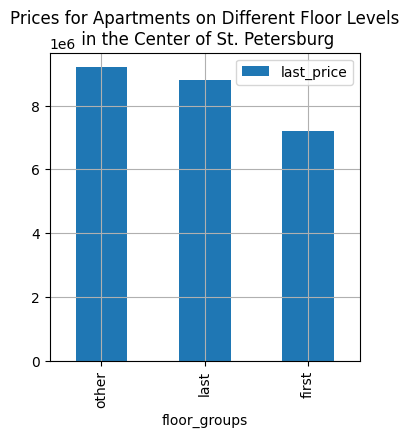

In [162]:
spb_center.pivot_table(index='floor_groups', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(4, 4))
plt.title('Prices for Apartments on Different Floor Levels\n in the Center of St. Petersburg')

    Looking at the graph, there are slightly more apartments on the "other floor" than on the top floor.
    The lowest prices are for apartments on the ground floor.

    Grouping the table by floor and looking at the median for each group, we see:
    1. The "other floor" group has the largest sample size, with a median of 9.2 million rubles.
    2. The median for the "top floor" group is 8.8 million.
    3. The median for the "first floor" group is 7.2 million.

**Distance from the Center**

<AxesSubplot:xlabel='center_km', ylabel='last_price'>

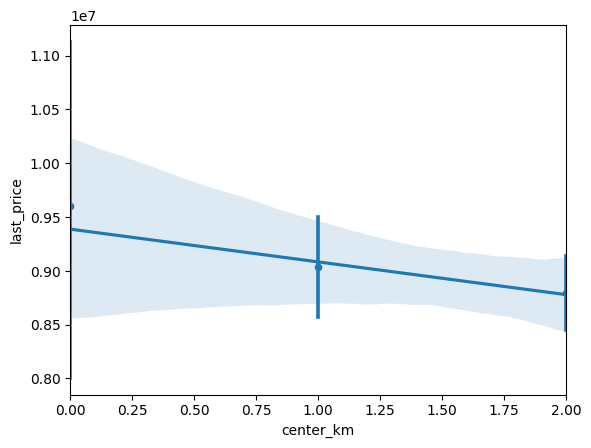

In [163]:
sns.regplot(x='center_km', y='last_price',data=spb_center, x_bins=40, scatter_kws={'s':20})

In [164]:
spb_center['center_km'].corr(spb_center['last_price']).round(2)

-0.06

    The graph shows a correlation with apartment location:
    - the closer the apartment is to the city center, the more expensive it is
    - the further the apartment is from the city center, the cheaper it is

    The Pearson coefficient is negative; 
    an increase in the "distance from the city center" value is associated 
    with a decrease in the "apartment price" value. In this case, the coefficient is not large (-0.06). 
    This may be due to the fact that our sample already includes apartments located in the city center.

**Date of Listing (Year, Month, Day of the Week)**

**Year**

In [165]:
spb_center.pivot_table(index='year', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False)

,count,median
year,,
2016,51,9500000
2018,96,9000000
2019,26,9000000
2015,38,8525000
2017,143,8500000


Text(0.5, 1.0, 'Apartment Prices by Years')

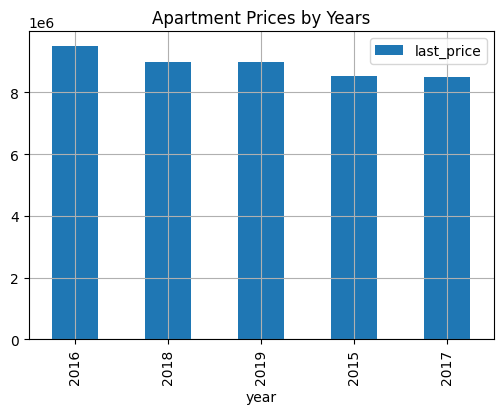

In [166]:
spb_center.pivot_table(index='year', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(6, 4))
plt.title('Apartment Prices by Years')

    The sample of listings for Central St. Petersburg contained no listings from 2014.
    The listings with the highest apartment prices were posted in 2016.

**Month**

In [167]:
spb_center.pivot_table(index='month', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False)

,count,median
month,,
9,39,9700000
3,35,9400000
5,19,9000000
8,22,8900000
1,23,8700000
12,30,8650000
10,25,8550000
7,39,8500000
11,29,8490000


Text(0.5, 1.0, 'Apartment Prices by Months')

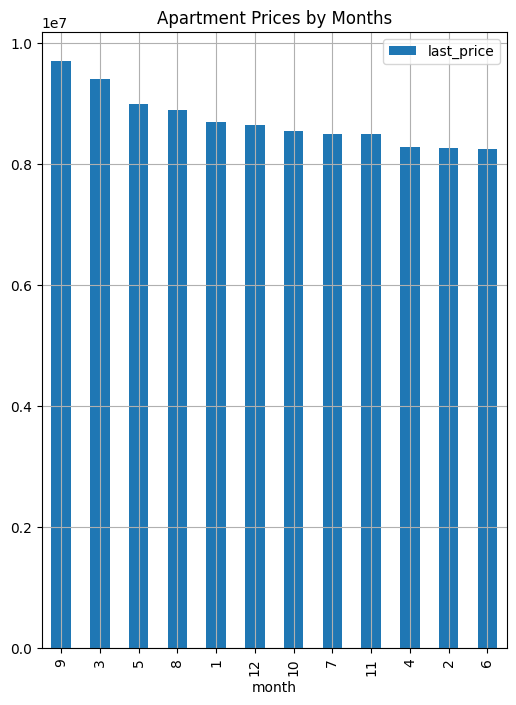

In [168]:
spb_center.pivot_table(index='month', values='last_price', aggfunc='median').sort_values('last_price',ascending=False).plot(kind='bar', grid=True, figsize=(6, 8))
plt.title('Apartment Prices by Months')

    The most expensive apartment listings were posted in September and March.
    The lowest prices were for apartments sold in June.

**Day of Week**

In [169]:
df.pivot_table(index='weekday', values='last_price', aggfunc=('count', 'median')).sort_values('median',ascending=False)

,count,median
weekday,,
1,4183,4730000
2,3974,4700000
0,3612,4650000
3,4295,4650000
4,4000,4585000
5,1936,4555000
6,1699,4550000


    It's impossible to determine the correlation between the price of an apartment and the day the ad was posted.
    This factor doesn't affect the price of an apartment, as it can be on the market 
    for anywhere from a month to several years.
    The exact day of the week the ad was posted doesn't affect the price.

### Step 5. General conclusion<a class="anchor" id="5-bullet"></a>

    To understand which factors influence apartment prices the most, the analysis was conducted using two databases:

    - a general dataset for St. Petersburg and the Leningrad Region
    - a segment of apartments in the center of St. Petersburg.

    The factors that most influence apartment prices are:
    - distance from the center (the closer the apartment is to the city center, the more expensive it is)
    - price per square meter (the higher the price per square meter, the more expensive the apartment)
    - area (the larger the area of ​​the apartment, the more expensive it is).

    The following factors have a lesser influence:
    - number of rooms (the more rooms in the apartment, the more expensive it is. Pearson coefficient: 0.37)
    - floor (the cheapest apartments are on the first floor, then on the top floor)
    - year of listing
    The "St. Petersburg + Leningrad Region" database and the "Center of St. Petersburg" database 
    yielded different results for apartment prices depending on the year.
    For the St. Petersburg + Leningrad Region sample, listings for expensive apartments were posted in 2014, 2015, and 2019. 
    In the "Central St. Petersburg" sample, listings for expensive apartments were posted in 2016, 2018, and 2019.
    For central St. Petersburg, listings for 2014 are not included in the sample.

    No effect:
    - day of listing
    - month of listing (The indicators differ little by month. The median of the most expensive month, 
    "April," differs from the median of "June" (the lowest apartment price) by only 8.3%).

    When comparing the indicators for the two databases, the following features were revealed:

    1. Apartment area in square meters.
    For the general database, the majority of apartments are 40-45 square meters.
    In central St. Petersburg, the majority of apartments are 70-80 square meters.

    2. Price.
    For the general database, the majority of apartments are priced between 3-4 million rubles. \
    In the central St. Petersburg apartment segment, the majority of apartments 
    are priced between 8.5 and 9 million rubles.

    3. Number of rooms
    In the general market, the majority are one-room apartments (this group also includes studio apartments).
    In the central St. Petersburg apartment segment, the majority are two-room apartments.

    4. Ceilings
    In the general market, the majority of apartments have ceilings in the 2.6-2.7 m range.
    In the central St. Petersburg apartment segment, the majority are apartments with ceilings in the 2.7-2.8 m range.

    On average, apartments take 45 to 60 days to sell.
    A sale can be considered quick if the transaction closed within 25 days (25% quartile - 22 days).
    A sale can be considered long-term if it took longer than 120 days (75% quartile - 199 days).

    The 10 settlements with the most listings are:
    St. Petersburg, Murino, Shushary, Vsevolozhsk, Pushkin, Kolpino, Pargolovo, Gatchina, Kudrovo, and Vyborg.